In [1]:
company_to_ticker = {
    "apple": "AAPL",
    "samsung": "005930.KS",
    "tcs": "TCS.NS",
    "microsoft": "MSFT",
    "google": "GOOGL",
    "amazon": "AMZN",
    "infosys": "INFY.NS",
    "wipro": "WIPRO.NS"

}


In [2]:
company_name = input("Enter company name (e.g., Apple, Samsung, TCS): ").lower()

if company_name in company_to_ticker:
    ticker = company_to_ticker[company_name]
    print(f"✅ Found ticker: {ticker}")
else:
    raise ValueError("❌ Company name not recognized. Please try a valid one.")


✅ Found ticker: TCS.NS


In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf



In [4]:
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential 
from tensorflow.keras.layers import LSTM, Dense

In [5]:
df = pd.read_csv('../data/stock_data.csv')

In [6]:

start_date = '2015-01-01'
end_date = '2024-01-01'

features = ['Close', 'Open', 'High', 'Low', 'Volume']
df = df[features]


In [7]:
df = yf.download(ticker, start=start_date, end=end_date)
df.to_csv('../data/stock_data.csv', index=False)

YF.download() has changed argument auto_adjust default to True


[*********************100%***********************]  1 of 1 completed


In [8]:
print(df.head())
print(df.describe())
print(df.columns)

Price             Close         High          Low         Open   Volume
Ticker           TCS.NS       TCS.NS       TCS.NS       TCS.NS   TCS.NS
Date                                                                   
2015-01-01  1049.376953  1058.219476  1047.501242  1058.219476   366830
2015-01-02  1063.351807  1068.092564  1051.458750  1051.623606   925740
2015-01-05  1047.192139  1071.782202  1040.761158  1063.990910  1754242
2015-01-06  1008.585938  1042.595721  1005.865115  1042.595721  2423784
2015-01-07   996.671875  1022.003984   992.446418  1018.232031  2636332
Price         Close         High          Low         Open        Volume
Ticker       TCS.NS       TCS.NS       TCS.NS       TCS.NS        TCS.NS
count   2221.000000  2221.000000  2221.000000  2221.000000  2.221000e+03
mean    2038.026305  2058.311053  2017.824046  2038.828565  2.696964e+06
std      924.941054   932.176890   917.492617   925.160413  2.471747e+06
min      895.757202   912.319805   874.760972   902.471613 

In [9]:
# Remove any non-numeric rows (like headers inside the data)
df = df[pd.to_numeric(df[('Close', ticker)], errors='coerce').notnull()]
df = df.astype(float)  # Convert all columns to float


In [10]:
scaler = MinMaxScaler()
scaled_data = scaler.fit_transform(df)

train_size = int(len(scaled_data) * 0.7)
train_data = scaled_data[:train_size]
test_data = scaled_data[train_size:]

def create_sequences(dataset, window_size=60):
    X, y = [], []
    for i in range(window_size, len(dataset)):
        X.append(dataset[i-window_size:i, 0])
        y.append(dataset[i, 0])
    return np.array(X), np.array(y)

window_size = 60
train_size = int(len(train_data) * 0.7)
X_train, y_train = create_sequences(train_data, window_size)
X_test, y_test = create_sequences(test_data, window_size)

X_train = np.reshape(X_train, (X_train.shape[0], X_train.shape[1], 1))
X_test = np.reshape(X_test, (X_test.shape[0], X_test.shape[1], 1))

In [11]:
model = Sequential()
model.add(LSTM(50, return_sequences=True, input_shape=(X_train.shape[1], 1)))
model.add(LSTM(50))
model.add(Dense(1))
model.compile(optimizer='adam', loss='mean_squared_error')

model.compile(loss='mean_squared_error', optimizer='adam')
# 

c:\Users\Nitin Saini\AppData\Local\Programs\Python\Python310\lib\site-packages\keras\src\layers\rnn\rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [12]:
model.fit(X_train, y_train, epochs=50, batch_size=32, validation_data=(X_test, y_test), verbose=1)

Epoch 1/50
47/47 ━━━━━━━━━━━━━━━━━━━━ 3s 28ms/step - loss: 0.0267 - val_loss: 0.0034
Epoch 2/50
47/47 ━━━━━━━━━━━━━━━━━━━━ 2s 36ms/step - loss: 5.5280e-04 - val_loss: 0.0019
Epoch 3/50
47/47 ━━━━━━━━━━━━━━━━━━━━ 3s 56ms/step - loss: 4.2699e-04 - val_loss: 0.0013
Epoch 4/50
47/47 ━━━━━━━━━━━━━━━━━━━━ 4s 81ms/step - loss: 4.4291e-04 - val_loss: 0.0012
Epoch 5/50
47/47 ━━━━━━━━━━━━━━━━━━━━ 3s 71ms/step - loss: 4.4388e-04 - val_loss: 0.0015
Epoch 6/50
47/47 ━━━━━━━━━━━━━━━━━━━━ 4s 84ms/step - loss: 4.6305e-04 - val_loss: 0.0011
Epoch 7/50
47/47 ━━━━━━━━━━━━━━━━━━━━ 4s 83ms/step - loss: 3.9713e-04 - val_loss: 0.0012
Epoch 8/50
47/47 ━━━━━━━━━━━━━━━━━━━━ 4s 80ms/step - loss: 3.4493e-04 - val_loss: 0.0011
Epoch 9/50
47/47 ━━━━━━━━━━━━━━━━━━━━ 4s 79ms/step - loss: 3.7418e-04 - val_loss: 0.0010
Epoch 10/50
47/47 ━━━━━━━━━━━━━━━━━━━━ 4s 80ms/step - loss: 3.5683e-04 - val_loss: 0.0013
Epoch 11/50
47/47 ━━━━━━━━━━━━━━━━━━━━ 4s 80ms/step - loss: 3.5394e-04 - val_loss: 7.4900e-04
Epoch 12/50
47/47 ━

In [13]:
predicted = model.predict(X_test)
predicted_price = scaler.inverse_transform(
    np.hstack([predicted, np.zeros((len(predicted), len(features)-1))])
)[:, 0]
real_price = scaler.inverse_transform(
    np.hstack([y_test.reshape(-1, 1), np.zeros((len(y_test), len(features)-1))])
)[:, 0]


19/19 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step


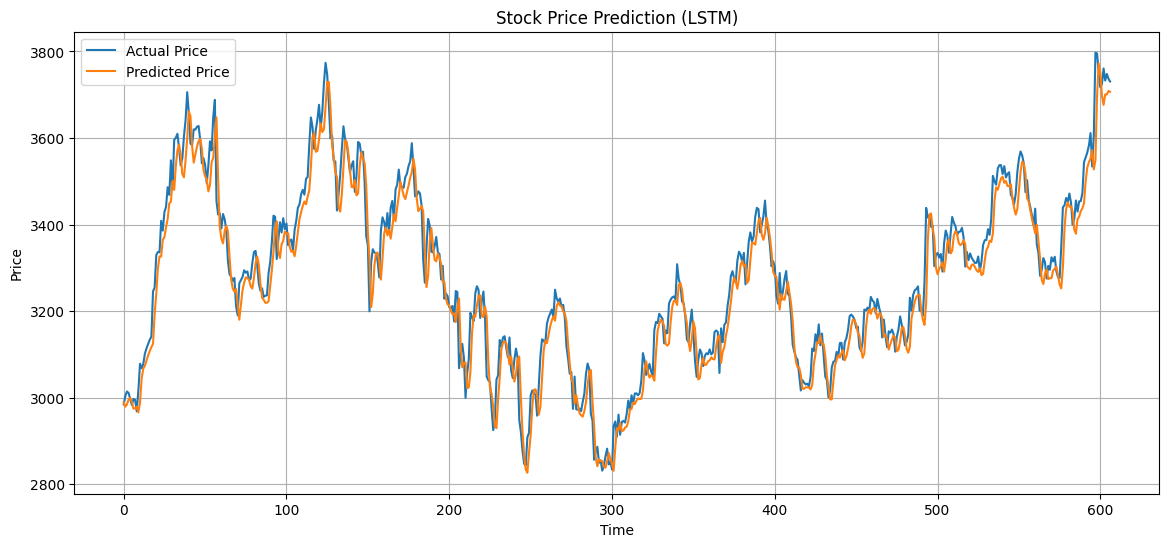

In [14]:
plt.figure(figsize=(14,6))
plt.plot(real_price, label='Actual Price')
plt.plot(predicted_price, label='Predicted Price')
plt.title("Stock Price Prediction (LSTM)")
plt.xlabel("Time")
plt.ylabel("Price")
plt.legend()
plt.grid()
plt.show()

In [15]:
# --- Step 7: Trading Signal Tool
signals = pd.DataFrame({'Actual': real_price, 'Predicted': predicted_price})
signals['Signal'] = np.where(signals['Predicted'].shift(-1) > signals['Predicted'], 'Buy', 'Sell')

print(signals.tail())

          Actual    Predicted Signal
602  3760.716797  3676.452402    Buy
603  3732.737549  3700.767064   Sell
604  3748.128662  3700.518904    Buy
605  3737.015625  3708.760755   Sell
606  3730.622803  3706.651654   Sell


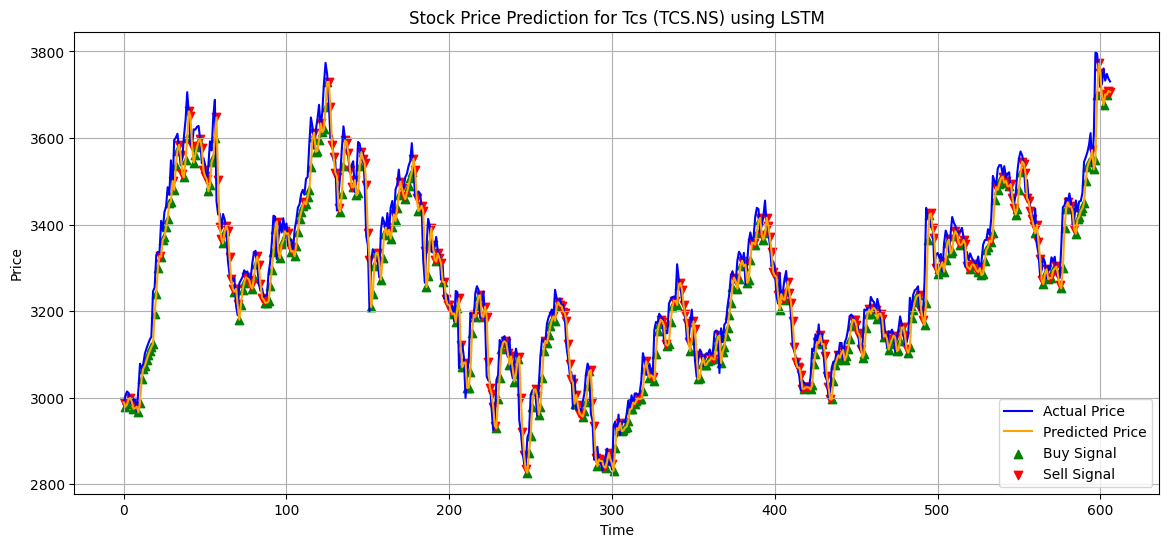

In [16]:
# --- Step 7: Trading Signal Tool

# --- Step 8: Plot Buy and Sell Signals on Price Chart
plt.figure(figsize=(14,6))

# Plot actual prices
plt.plot(real_price, label='Actual Price', color='blue')

# Plot predicted prices
plt.plot(predicted_price, label='Predicted Price', color='orange')

# Plot Buy signals
buy_signals = signals[signals['Signal'] == 'Buy']
plt.scatter(buy_signals.index, buy_signals['Predicted'], marker='^', color='green', label='Buy Signal', alpha=1)

# Plot Sell signals
sell_signals = signals[signals['Signal'] == 'Sell']
plt.scatter(sell_signals.index, sell_signals['Predicted'], marker='v', color='red', label='Sell Signal', alpha=1)

# Labels and title
plt.title(f"Stock Price Prediction for {company_name.capitalize()} ({ticker}) using LSTM")
plt.xlabel("Time")
plt.ylabel("Price")
plt.legend()
plt.grid()
plt.show()


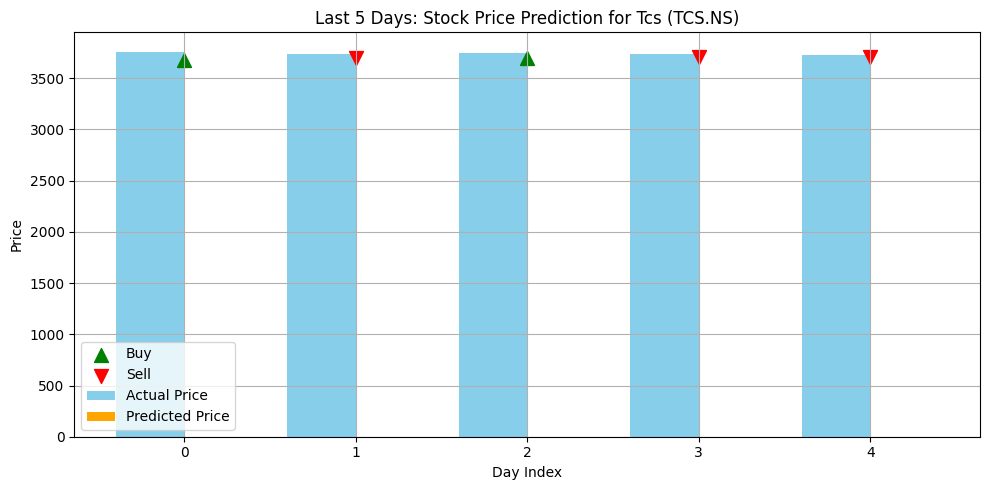

In [17]:
# Select only the last 5 data points
num_days = 5
real_last5 = real_price[-num_days:]
pred_last5 = predicted[-num_days:].flatten()
indices = list(range(len(real_price)))[-num_days:]

# Filter signals for last 5 days
signals_last5 = signals.iloc[-num_days:]
buy_last5 = signals_last5[signals_last5['Signal'] == 'Buy']
sell_last5 = signals_last5[signals_last5['Signal'] == 'Sell']

# Plotting
plt.figure(figsize=(10,5))
bar_width = 0.4

# Actual prices
plt.bar([i - bar_width/2 for i in range(num_days)], real_last5, width=bar_width, label='Actual Price', color='skyblue')

# Predicted prices
plt.bar([i + bar_width/2 for i in range(num_days)], pred_last5, width=bar_width, label='Predicted Price', color='orange')

# Buy/Sell signals
for i, row in buy_last5.iterrows():
    plt.scatter(i - indices[0], row['Predicted'], color='green', marker='^', s=100, label='Buy' if i == buy_last5.index[0] else "")

for i, row in sell_last5.iterrows():
    plt.scatter(i - indices[0], row['Predicted'], color='red', marker='v', s=100, label='Sell' if i == sell_last5.index[0] else "")

# Title and labels
plt.title(f"Last 5 Days: Stock Price Prediction for {company_name.capitalize()} ({ticker})")
plt.xlabel("Day Index")
plt.ylabel("Price")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


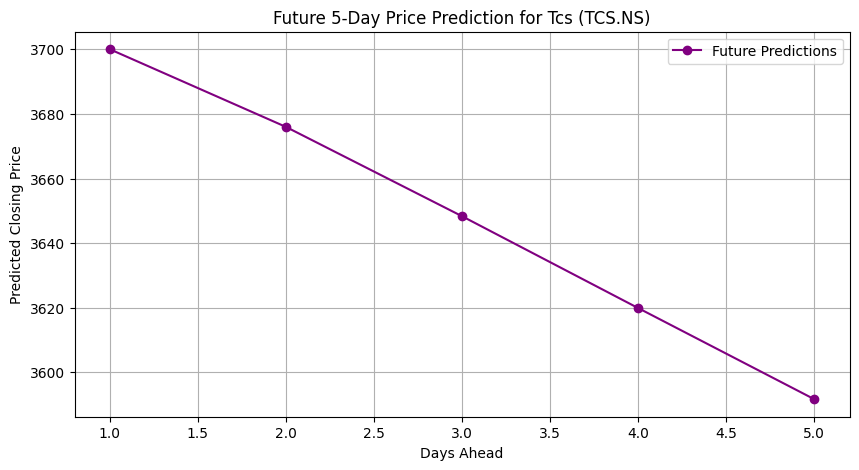

In [18]:
# Start with the last sequence of known data
last_sequence = test_data[-window_size:]  # shape: (60, 5)
last_close_sequence = last_sequence[:, 0]  # only 'Close' feature

future_preds = []

input_seq = last_close_sequence.copy()

for _ in range(5):
    input_reshaped = input_seq.reshape(1, window_size, 1)  # LSTM expects 3D
    pred = model.predict(input_reshaped, verbose=0)
    future_preds.append(pred[0][0])

    # Slide window: remove oldest, append new prediction
    input_seq = np.append(input_seq[1:], pred[0][0])

# Inverse scale predictions to get actual prices
future_preds_actual = scaler.inverse_transform(
    np.hstack([np.array(future_preds).reshape(-1, 1), np.zeros((5, len(features)-1))])
)[:, 0]

# Plot future predictions
plt.figure(figsize=(10, 5))
plt.plot(range(1, 6), future_preds_actual, marker='o', linestyle='-', color='purple', label='Future Predictions')
plt.title(f"Future 5-Day Price Prediction for {company_name.capitalize()} ({ticker})")
plt.xlabel("Days Ahead")
plt.ylabel("Predicted Closing Price")
plt.grid(True)
plt.legend()
plt.show()


In [19]:
df.info()


<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 2221 entries, 2015-01-01 to 2023-12-29
Data columns (total 5 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   (Close, TCS.NS)   2221 non-null   float64
 1   (High, TCS.NS)    2221 non-null   float64
 2   (Low, TCS.NS)     2221 non-null   float64
 3   (Open, TCS.NS)    2221 non-null   float64
 4   (Volume, TCS.NS)  2221 non-null   float64
dtypes: float64(5)
memory usage: 104.1 KB


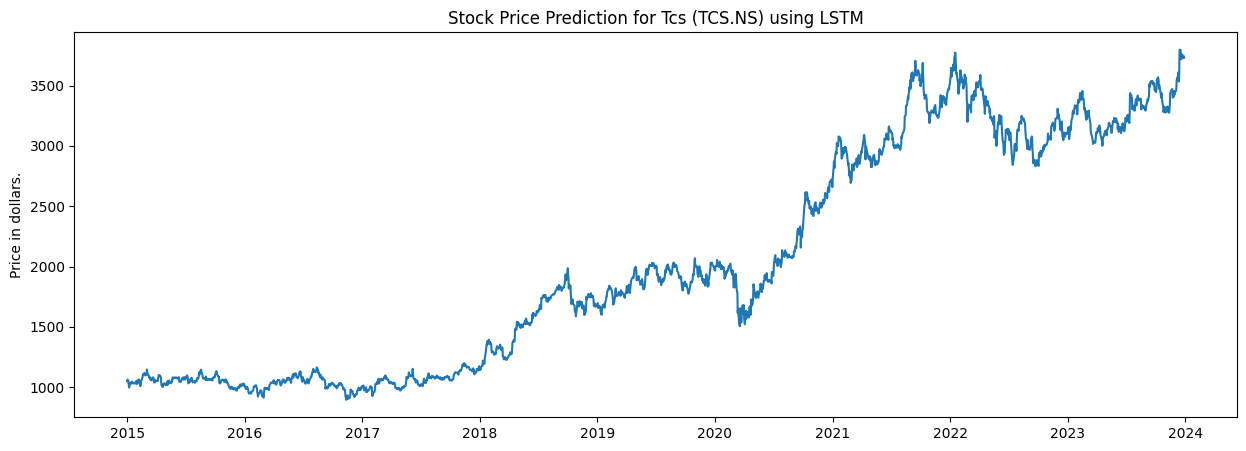

In [22]:
plt.figure(figsize=(15,5))
plt.plot(df['Close'])
plt.title(f"Stock Price Prediction for {company_name.capitalize()} ({ticker}) using LSTM")
plt.ylabel('Price in dollars.')
plt.show()